In [62]:
import fastf1
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.patches import FancyBboxPatch


def plot_track_dominance(
    session,
    driver1=None,
    driver2=None,
    color1='#2FA3DC',
    color2='#0018F9',
    linewidth=4,
    figsize=(10, 10)
):
    results = session.results.copy()

    if driver1 is None:
        driver1 = results.loc[results['Position'] == 1, 'Abbreviation'].iloc[0]
    if driver2 is None:
        driver2 = results.loc[results['Position'] == 2, 'Abbreviation'].iloc[0]

    lap1 = session.laps.pick_drivers(driver1).pick_fastest()
    lap2 = session.laps.pick_drivers(driver2).pick_fastest()

    tel1 = lap1.get_telemetry().add_distance()
    tel2 = lap2.get_telemetry().add_distance()

    dist = np.linspace(0, min(tel1['Distance'].max(), tel2['Distance'].max()), 2000)

    speed1 = np.interp(dist, tel1['Distance'], tel1['Speed'])
    speed2 = np.interp(dist, tel2['Distance'], tel2['Speed'])

    x = np.interp(dist, tel1['Distance'], tel1['X'])
    y = np.interp(dist, tel1['Distance'], tel1['Y'])

    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    faster = speed1 > speed2
    colors = np.where(faster[:-1], color1, color2)
    lc = LineCollection(segments, colors=colors, linewidth=linewidth)

    pct1 = np.mean(faster) * 100
    pct2 = 100 - pct1

    tel_sector = tel1.copy()
    tel_sector['TimeSeconds'] = tel_sector['Time'].dt.total_seconds()

    s1_end = lap1['Sector1Time'].total_seconds()
    s2_end = s1_end + lap1['Sector2Time'].total_seconds()

    def time_to_distance(target_time, tel):
        idx = (tel['TimeSeconds'] - target_time).abs().idxmin()
        return tel.loc[idx, 'Distance']

    d_s1 = time_to_distance(s1_end, tel_sector)
    d_s2 = time_to_distance(s2_end, tel_sector)

    sector_distances = {
        'S/F': 0,
        'S2': d_s1,
        'S3': d_s2
    }

    sector_points = {}
    for label, d in sector_distances.items():
        sx = np.interp(d, tel1['Distance'], tel1['X'])
        sy = np.interp(d, tel1['Distance'], tel1['Y'])
        sector_points[label] = (sx, sy)

    fig, ax = plt.subplots(figsize=figsize, facecolor='black')
    ax.set_facecolor('black')

    ax.add_collection(lc)
    ax.autoscale()
    ax.margins(0.12)
    ax.set_aspect('equal')
    ax.axis('off')

    for label, (sx, sy) in sector_points.items():
        ax.plot(sx, sy, marker='|', color='white', markersize=18, markeredgewidth=2.5)
        ax.text(
            sx + 80, sy + 80, label,
            color='white',
            fontsize=10,
            weight='bold',
            bbox=dict(facecolor='black', edgecolor='white',
                      boxstyle='round,pad=0.25', alpha=0.85)
        )

    ax.set_title(
        f"{session.event['EventName']} {session.event.year}\n"
        f"Track Dominance — {driver1} vs {driver2}",
        fontsize=18,
        color='white',
        weight='bold',
        pad=20
    )

    # Top-right driver labels
    ax.text(
        0.82, 0.92,
        driver1,
        transform=ax.transAxes,
        color=color1,
        fontsize=15,
        weight='bold',
        ha='center',
        va='center',
        bbox=dict(facecolor='black', edgecolor=color1,
                  boxstyle='round,pad=0.35', linewidth=2)
    )

    ax.text(
        0.92, 0.92,
        driver2,
        transform=ax.transAxes,
        color=color2,
        fontsize=15,
        weight='bold',
        ha='center',
        va='center',
        bbox=dict(facecolor='black', edgecolor=color2,
                  boxstyle='round,pad=0.35', linewidth=2)
    )

    # Footer box
    footer_box = FancyBboxPatch(
        (0.12, 0.035), 0.76, 0.05,
        boxstyle="round,pad=0.006,rounding_size=0.01",
        transform=fig.transFigure,
        linewidth=1.2,
        edgecolor='white',
        facecolor='black',
        alpha=0.9
    )
    fig.patches.append(footer_box)

    # Footer text inside box
    fig.text(
        0.29, 0.058,
        f"{driver1} — faster {pct1:.0f}% of lap",
        ha='center',
        va='center',
        color=color1,
        fontsize=12
    )

    fig.text(
        0.50, 0.058,
        "|",
        ha='center',
        va='center',
        color='white',
        fontsize=12
    )

    fig.text(
        0.71, 0.058,
        f"{driver2} — faster {pct2:.0f}% of lap",
        ha='center',
        va='center',
        color=color2,
        fontsize=12
    )

    plt.show()

    return 

core           INFO 	Loading data for Australian Grand Prix - Qualifying [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 18
core        WARNING 	No lap data for driver 55
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 18)
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 55)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_c

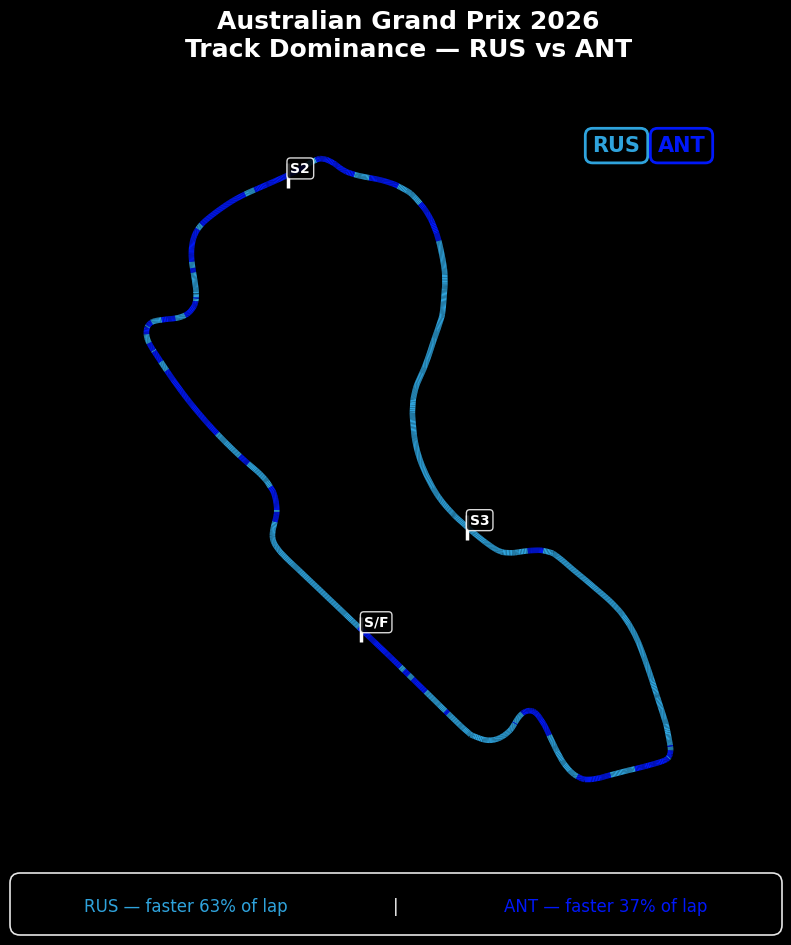

In [63]:
aus_session = fastf1.get_session(2026, 'Australian Grand Prix', 'Q')
aus_session.load(telemetry=True)

plot_track_dominance(aus_session)

core           INFO 	Loading data for Chinese Grand Prix - Qualifying [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['12', '63', '44', '16', '81', '1', '10', '3', '6', '87', '27', '43', '31', '30', '41', '5', '55', '23', '14', '77', '18', '11']


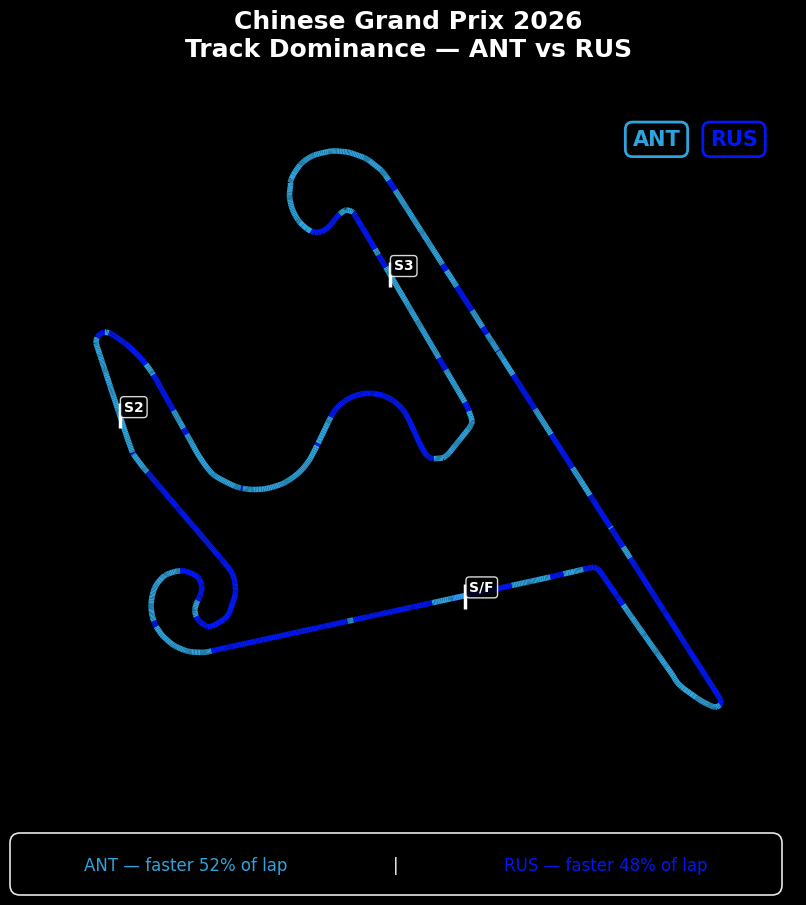

In [64]:
chn_session = fastf1.get_session(2026, 'Chinese Grand Prix', 'Q')
chn_session.load(telemetry=True)

plot_track_dominance(chn_session)

